In [5]:
# Setup
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import copy

from utils.data_reader import load_and_prepare_time_series_data
from utils.trainer import Trainer
from utils.evaluator import Evaluator
from models.baseline_models import LSTMModel, BiLSTMModel, GRUModel
from models.custom_models import MGSSMsModel, ExtendedMGSSMsModel

In [ ]:
import pandas as pd

# Load the original CSV file
df = pd.read_csv("/home/theppawan/nn-models/data/bangkok_solar_data.csv")

# Filter the data to keep only rows where 'GHI' is 10 or higher
filtered_df = df[df['GHI'] >= 10]

# Save the cleaned data to a new CSV file
filtered_df.to_csv('/home/theppawan/nn-models/data/bangkok_solar_data_filtered.csv', index=False)

In [6]:
train_loader, val_loader, test_loader, scaler = load_and_prepare_time_series_data(
    filepath_or_url = "/home/theppawan/nn-models/data/bangkok_solar_data.csv",
    target_column=['GHI'],
    date_column='datetime',
    seq_length=14,
    batch_size=64,
    train_split=0.8,
    fill_missing=True)

Fetching data from: /home/theppawan/nn-models/data/bangkok_solar_data.csv
Sorting data chronologicall by column: datetime
Succesfully loaded 17520 sequential data points.
Prepared:
    --> Training batches: 219
    --> Validation batches: 28
    --> Testing batches: 28


In [7]:
# Setup model configurations
model_config_dict = {
    "Baseline LSTM": LSTMModel(input_size=1, hidden_size=16, num_layers=1, output_size=1),
    "Baseline BiLSTM": BiLSTMModel(input_size=1, hidden_size=256, num_layers=1, output_size=1),
    "Baseline GRU": GRUModel(input_size=1, hidden_size=16, num_layers=1, output_size=1),
    "MGSSMs": MGSSMsModel(input_size=1, hidden_size=128, num_layers=1, output_size=1, gate_size=32),
    "ExtendedMGSSMs": ExtendedMGSSMsModel(input_size=1, hidden_size=256, num_layers=1, output_size=1, gate_size=32, p=2)
}

In [8]:
model_trained = []
for name, model in model_config_dict.items():
    print(f"Training model: {name}")
    trainer = Trainer(
        model=model,
        criterion=nn.MSELoss(),
        optimizer=optim.Adam(model.parameters(), lr=0.001),
        device="cpu"
    )
    train_loader = train_loader
    val_loader = val_loader
    trainer.train(train_loader=train_loader, val_loader=val_loader, epochs=1000, patience=50, label=f'solar2022')

Training model: Baseline LSTM
Starting training on device: cpu


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping triggered after 177 epochs.
Training complete! Best validation loss: 0.0058. Model saved to checkpoints/best_LSTMModel_solar2022.pth
Training model: Baseline BiLSTM
Starting training on device: cpu


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping triggered after 103 epochs.
Training complete! Best validation loss: 0.0057. Model saved to checkpoints/best_BiLSTMModel_solar2022.pth
Training model: Baseline GRU
Starting training on device: cpu


...

Early stopping triggered after 172 epochs.
Training complete! Best validation loss: 0.0058. Model saved to checkpoints/best_GRUModel_solar2022.pth
Training model: MGSSMs
Starting training on device: cpu


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping triggered after 90 epochs.
Training complete! Best validation loss: 0.0072. Model saved to checkpoints/best_MGSSMsModel_solar2022.pth
Training model: ExtendedMGSSMs
Starting training on device: cpu


Training Model:   0%|          | 0/1000 [00:00<?, ?it/s]

Early stopping triggered after 58 epochs.
Training complete! Best validation loss: 0.0069. Model saved to checkpoints/best_ExtendedMGSSMsModel_solar2022.pth


#### Get All Results

In [15]:
def plot_predictions(model, test_loader, scaler):
    model.eval()
    
    actuals = []
    predictions = []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            preds = model(batch_x)
            actuals.extend(batch_y.cpu().numpy().flatten())
            predictions.extend(preds.cpu().numpy().flatten())

    predictions = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))
    actuals = scaler.inverse_transform(np.array(actuals).reshape(-1, 1))
    
    # Calculate the difference (residual)
    differences = actuals - predictions
            
    # Create subplots: 2 rows, 1 column. 
    # height_ratios=[3, 1] makes the top plot 3x taller than the bottom plot.
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    
    # --- Top Subplot: Actuals vs Predictions ---
    ax1.plot(actuals, label="Actual GHI", color="blue")
    ax1.plot(predictions, label="Model Predictions", color="red", linestyle="--")
    ax1.set_title(f"{model.__class__.__name__} Forecasting on Solar irradiance at Bangkok")
    ax1.set_ylabel("GHI")
    ax1.set_xlim(200, 300) # Applies to both due to sharex=True
    ax1.legend()
    ax1.grid(True)
    
    # --- Bottom Subplot: Difference / Error ---
    ax2.plot(differences, label="Difference (Actual - Prediction)", color="purple")
    ax2.axhline(0, color='black', linestyle='--', linewidth=1) # Adds a baseline at zero
    ax2.set_xlabel("hours")
    ax2.set_ylabel("Error")
    ax2.legend(loc="upper left")
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

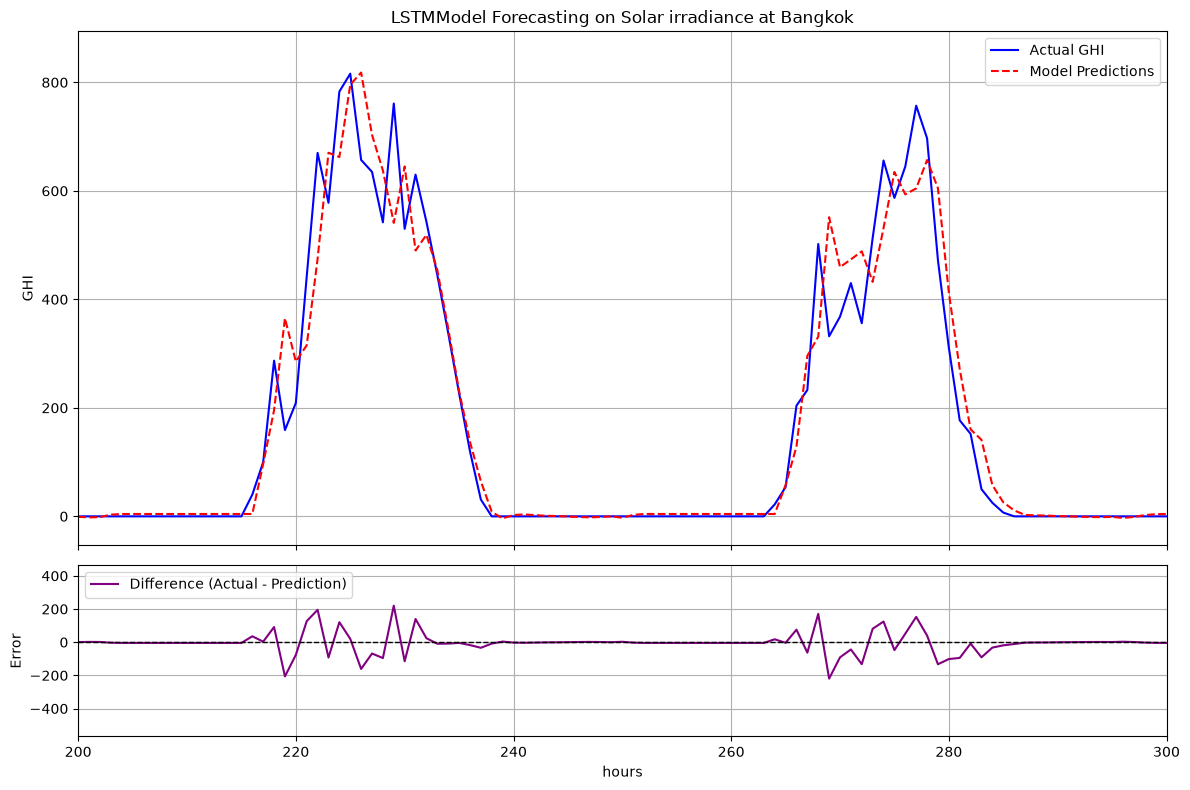

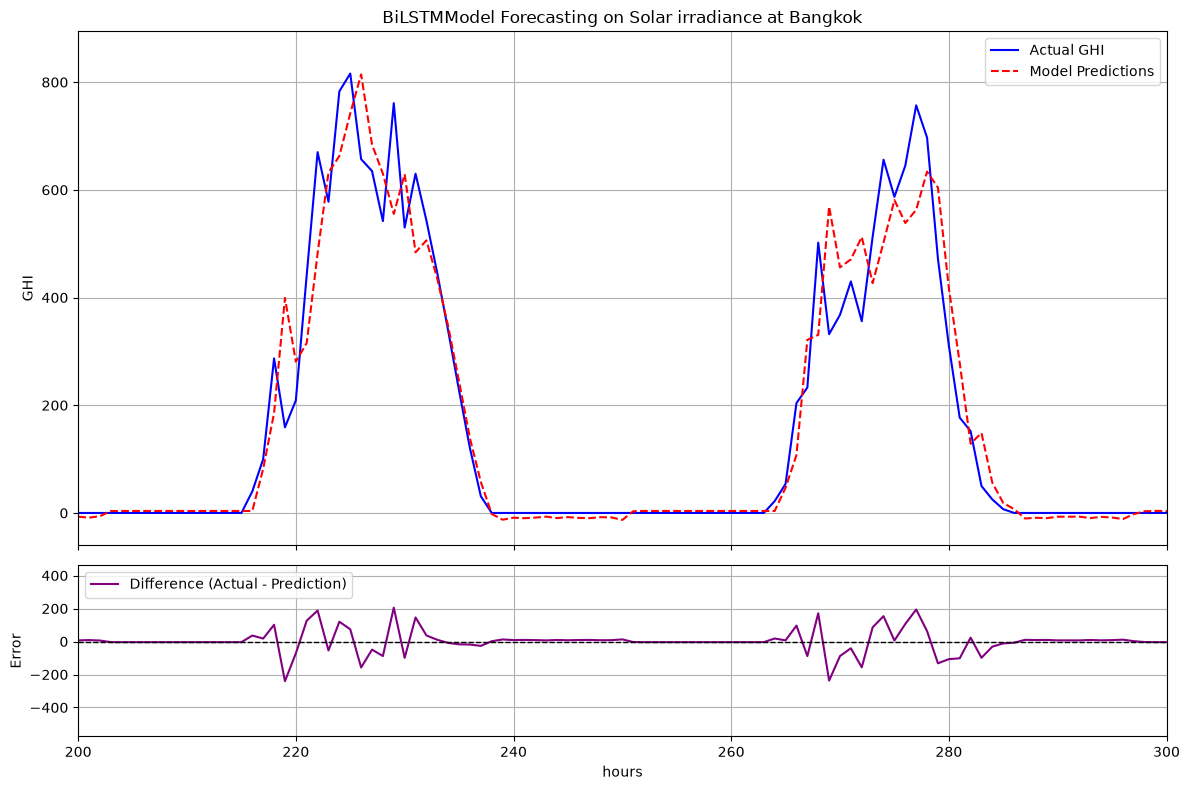

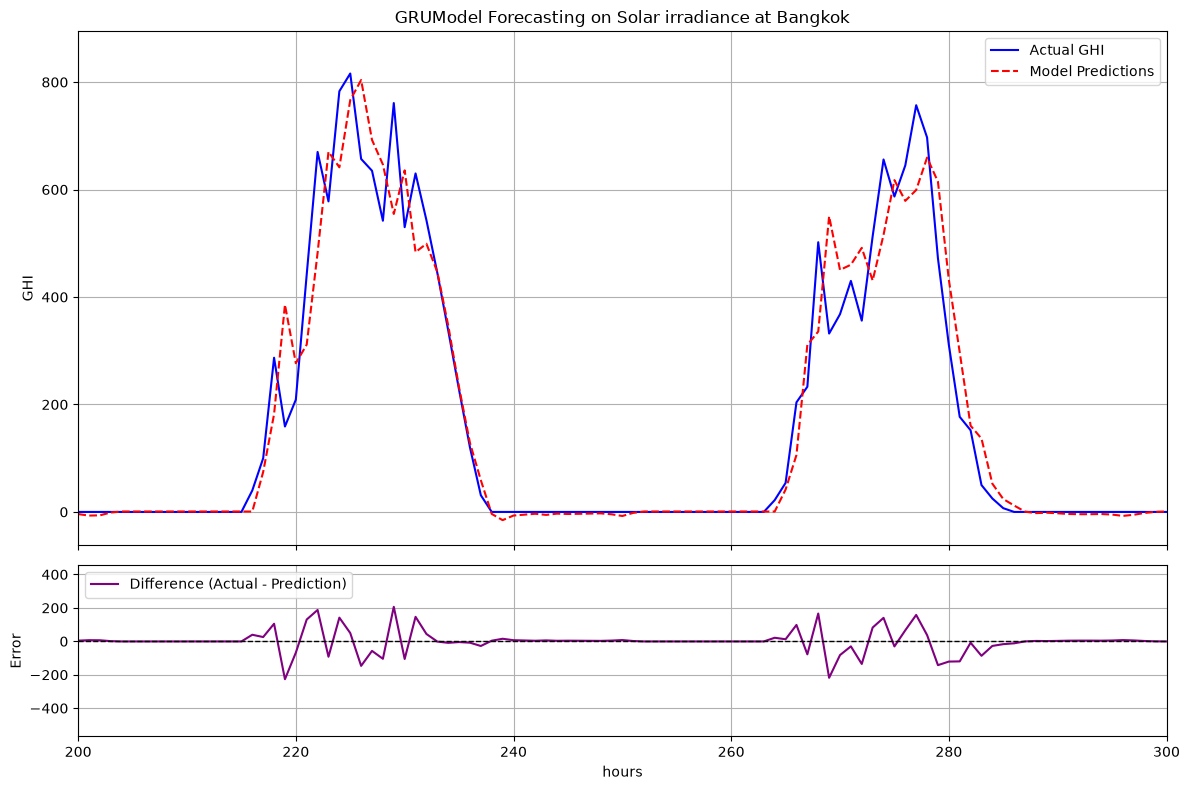

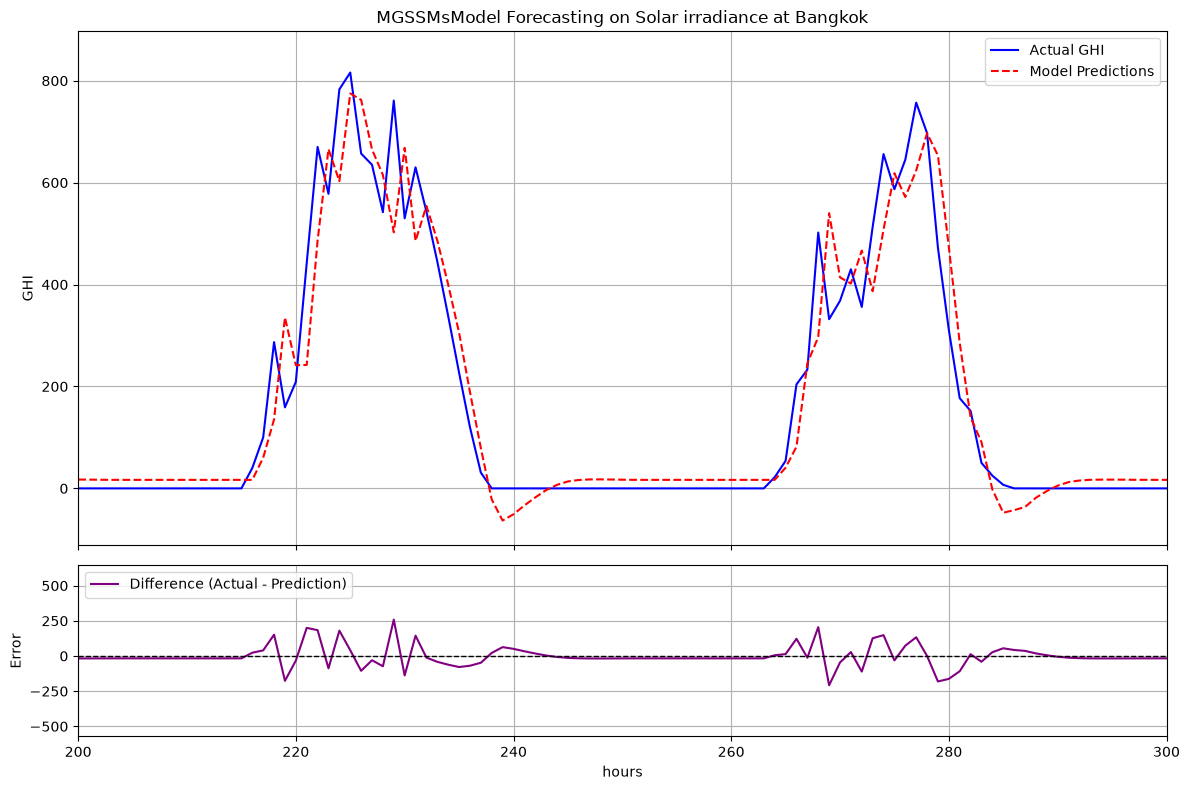

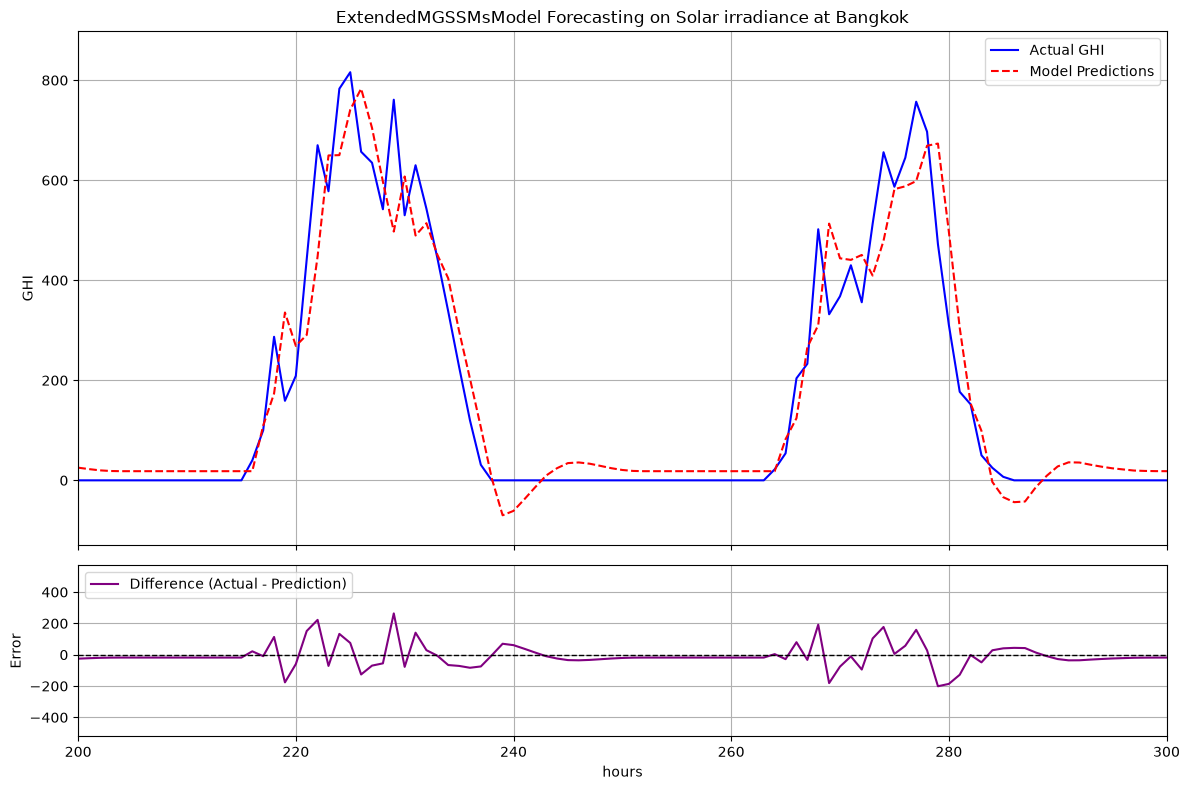

In [16]:
for model_config in model_config_dict.values():
    # analyze the model from the checkpoint
    model_config.load_state_dict(torch.load(f"checkpoints/best_{model_config.__class__.__name__}_solar2022.pth"))
    plot_predictions(model_config, test_loader, scaler)

In [14]:
test_loader_dist = {'2022': test_loader}
scaler_dist = {'2022': scaler}
trained_model_dict = {}
# loading the checkpointed models
for model_name, model_config in model_config_dict.items():
    # analyze the model from the checkpoint
        specific_model = copy.deepcopy(model_config)
        specific_model.load_state_dict(torch.load(f"checkpoints/best_{model_config.__class__.__name__}_solar2022.pth"))
        trained_model_dict[model_name] = specific_model

evaluator = Evaluator()
evaluator.compare_models(trained_model_dict, test_loader_dist['2022'], scaler_dist['2022'])

Evaluating model: Baseline LSTM...
Evaluating model: Baseline BiLSTM...
Evaluating model: Baseline GRU...
Evaluating model: MGSSMs...
Evaluating model: ExtendedMGSSMs...


,MSE,RMSE,MAE,R2,MAPE,Adjusted MAPE
Model,,,,,,
Baseline LSTM,4532.895508,67.326782,27.457005,0.939598,8.724860e+15,1952.332886
Baseline BiLSTM,4648.896973,68.182820,30.176842,0.938052,1.495303e+16,3335.359619
Baseline GRU,4466.284668,66.830268,28.573235,0.940485,8.405868e+15,1881.539307
MGSSMs,5807.161133,76.204732,43.725536,0.922618,4.426927e+16,9849.121094
ExtendedMGSSMs,5509.035156,74.222875,45.115997,0.926590,5.557153e+16,12359.848633


In [ ]:
performance_data = evaluator.build_performance_dataframe(nested_models_dict=trained_model_dict, data_loaders_dict=test_loader_dist, scalers_dict=scaler_dist, target_metric="MSE")
performance_data